**Mount Drive (Google Colab)**

In [1]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [9]:
import pandas as pd

pima_data = pd.read_csv('drive/My Drive/Datasets For ML/Pima Indians Diabetes.csv')

print("Shape:", pima_data.shape)
print("\nDuplicated:", pima_data.duplicated().sum())
print("\nNull Values:", pima_data.isnull().sum().sum())
print("\nFirst 2 Rows:")
pima_data.head(2)

Shape: (768, 9)

Duplicated: 0

Null Values: 0

First 2 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


**Feature–Label Separation**

X → Medical predictor variables

Y → Diabetes outcome (0 = No, 1 = Yes)

In [3]:
X, Y = pima_data.iloc[:, :-1], pima_data.iloc[:, -1]

**Train–Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (537, 8)
X_test: (231, 8)


**Feature Scaling**

Used StandardScaler

Required because logistic regression is sensitive to feature magnitude.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Generalized Logistic Regression Model**

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=42
)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
Y_proba = model.predict_proba(X_test)[:,1]

**Reason:**

L2 regularization prevents overfitting.

class_weight='balanced' handles mild class imbalance.

liblinear is efficient for small/medium datasets.

**Model Evaluation**

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba))

Accuracy: 0.7705627705627706
F1 Score: 0.6863905325443787
ROC-AUC: 0.836954732510288


**3D Decision Hyperplane Visualization (PCA Projection)**

Since the original decision boundary lies in 8-dimensional space, PCA is used to project the data into 3 principal components, enabling visualization of the logistic regression hyperplane as a 3D plane.

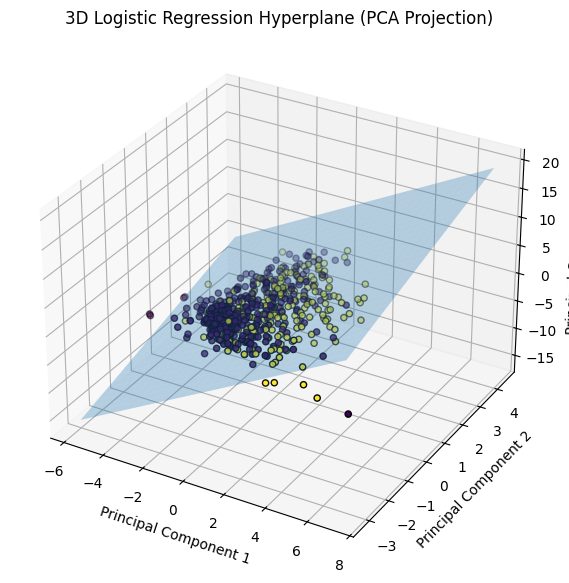

In [8]:
# 3D Hyperplane Visualization using PCA

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# PCA to 3 components
pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train)

# Train Logistic Regression on 3D PCA data
model_3d = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=42
)
model_3d.fit(X_train_pca_3d, Y_train)

# Create meshgrid for hyperplane
x_min, x_max = X_train_pca_3d[:, 0].min() - 1, X_train_pca_3d[:, 0].max() + 1
y_min, y_max = X_train_pca_3d[:, 1].min() - 1, X_train_pca_3d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 30),
    np.linspace(y_min, y_max, 30)
)

# Hyperplane equation: w1*x + w2*y + w3*z + b = 0
w1, w2, w3 = model_3d.coef_[0]
b = model_3d.intercept_[0]

zz = (-w1 * xx - w2 * yy - b) / w3

# Plot 3D scatter and plane
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train_pca_3d[:, 0],
    X_train_pca_3d[:, 1],
    X_train_pca_3d[:, 2],
    c=Y_train,
    edgecolor='k'
)

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D Logistic Regression Hyperplane (PCA Projection)")

plt.show()

**Conclusion**

Logistic Regression is an effective model for diabetes prediction using medical features. L2 regularization helps prevent overfitting and improves generalization, while class balancing handles class imbalance. Evaluation using ROC-AUC and F1-score shows the model can effectively distinguish between classes. The model provides interpretable results through its coefficients.
